In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from statistics import median

In [79]:
Clean_Data = pd.read_excel('2023_Data_BiomassGasification_NED.xlsx', sheet_name='Clean Data')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
Clean_Data

,ID,feed_type,feed_shape,feed_particle_size,feed_LHV,C,H,N,S,O,...,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE,Reference
0,1,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,...,13.36,4.18,2.19,5.39,73.00,1.62,NaN,53.00,70.00,"Arena, Fuel 2014, 117, 528-536"
1,2,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,...,15.69,4.20,2.72,5.65,47.00,1.73,NaN,56.00,80.00,"Arena, Fuel 2014, 117, 528-536"
2,3,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,...,12.28,4.57,2.14,5.55,58.00,1.72,NaN,58.00,75.00,"Arena, Fuel 2014, 117, 528-536"
3,4,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,...,12.83,4.35,2.05,5.16,39.00,1.91,NaN,61.00,81.00,"Arena, Fuel 2014, 117, 528-536"
4,5,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,...,14.04,3.33,1.78,4.91,5.00,2.04,NaN,61.00,92.00,"Arena, Fuel 2014, 117, 528-536"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,404,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,...,31.44,8.06,0.66,9.23,NaN,NaN,NaN,80.41,67.07,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
404,405,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,...,16.38,2.62,0.01,4.05,NaN,NaN,NaN,61.23,62.42,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
405,406,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,...,15.81,3.43,0.02,4.71,NaN,NaN,NaN,62.60,57.36,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."
406,407,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,...,16.10,2.95,0.01,4.40,NaN,NaN,NaN,61.10,57.64,"Yong-Seong Jeong et al.,Renewable Energy 185 2..."


In [80]:
input_var = ['feed_type', 'feed_shape', 'feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'O', 'feed_ash', 'feed_moisture', 'feed_VM', 'feed_FC', 'feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'temperature', 'operating_condition', 'operating_pressure', 'residence_time', 'Steam/Biomass', 'ER', 'gasifying_agent', 'reactor_type', 'bed_material', 'catalyst', 'scale']
clean_input = Clean_Data.loc[:, Clean_Data.columns.isin(input_var)]
clean_input


,feed_type,feed_shape,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,...,operating_condition,operating_pressure,residence_time,Steam/Biomass,ER,gasifying_agent,reactor_type,bed_material,catalyst,scale
0,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.26,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
1,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.26,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
2,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.27,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
3,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.30,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
4,municipal solid waste,pellets,5.00,19.45,59.39,8.57,0.93,0.27,32.30,20.69,...,continuous,NaN,120.00,NaN,0.32,air,fluidised bed,olivine,1.00,pilot-scale (400 kW_th)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,33.00,0.67,0.44,steam/oxygen,fluidised bed,NaN,NaN,pilot-scale
404,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,280.00,NaN,0.41,air,fluidised bed,NaN,NaN,pilot-scale
405,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,225.00,NaN,0.33,air,fluidised bed,NaN,NaN,pilot-scale
406,sewage sludge,particles,2.00,13.25,52.28,7.82,6.67,1.90,31.33,42.59,...,continuous,NaN,242.00,NaN,0.35,air,fluidised bed,NaN,NaN,pilot-scale


In [81]:
output_var = ['N2', 'H2', 'CO', 'CO2', 'CH4', 'C2Hn', 'gas_LHV', 'gas_tar', 'gas_yield', 'char_yield', 'CGE', 'CCE']
clean_output = Clean_Data.loc[:, Clean_Data.columns.isin(output_var)]
clean_output

,N2,H2,CO,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE
0,61.77,8.48,9.74,13.36,4.18,2.19,5.39,73.00,1.62,NaN,53.00,70.00
1,60.64,7.11,8.98,15.69,4.20,2.72,5.65,47.00,1.73,NaN,56.00,80.00
2,61.67,8.44,10.47,12.28,4.57,2.14,5.55,58.00,1.72,NaN,58.00,75.00
3,61.86,8.24,10.40,12.83,4.35,2.05,5.16,39.00,1.91,NaN,61.00,81.00
4,60.66,7.08,12.73,14.04,3.33,1.78,4.91,5.00,2.04,NaN,61.00,92.00
...,...,...,...,...,...,...,...,...,...,...,...,...
403,3.05,38.79,18.01,31.44,8.06,0.66,9.23,NaN,NaN,NaN,80.41,67.07
404,52.61,16.75,11.63,16.38,2.62,0.01,4.05,NaN,NaN,NaN,61.23,62.42
405,50.10,18.75,11.90,15.81,3.43,0.02,4.71,NaN,NaN,NaN,62.60,57.36
406,51.51,18.60,10.83,16.10,2.95,0.01,4.40,NaN,NaN,NaN,61.10,57.64


In [82]:
clean_input.describe()

,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,feed_moisture,feed_VM,feed_FC,feed_cellulose,feed_hemicellulose,feed_lignin,temperature,residence_time,Steam/Biomass,ER,catalyst
count,316.00,408.00,408.00,408.00,408.00,375.00,408.00,408.00,408.00,360.00,318.00,28.00,28.00,28.00,408.00,156.00,136.00,335.00,308.00
mean,4.52,19.27,53.16,7.12,1.05,0.34,37.99,8.76,7.64,77.11,14.23,39.42,20.91,24.99,805.01,89.92,0.97,0.29,0.27
std,6.29,8.11,10.91,2.30,1.82,0.49,12.80,12.48,5.99,10.57,5.62,5.08,4.67,5.39,71.77,94.17,0.71,0.10,0.44
min,0.25,11.50,40.07,3.79,0.00,0.00,0.00,0.27,0.00,52.03,0.00,29.60,14.00,14.00,553.00,6.00,0.00,0.09,0.00
25%,1.25,14.47,48.32,5.90,0.15,0.00,33.75,1.00,5.13,67.95,11.53,37.53,18.90,23.84,770.00,40.00,0.50,0.23,0.00
50%,3.50,18.08,50.00,6.25,0.44,0.10,42.20,2.05,7.65,80.30,14.77,38.50,19.50,25.90,800.00,40.00,0.80,0.30,0.00
75%,5.00,19.45,53.31,7.12,0.97,0.57,44.71,13.90,9.34,83.17,17.16,43.50,24.40,26.68,850.00,80.00,1.22,0.32,1.00
max,70.00,45.10,86.03,14.23,7.32,1.90,53.40,44.00,51.02,99.00,31.80,46.20,29.60,33.00,1050.00,403.00,4.04,0.87,1.00


In [83]:
clean_output.describe()

,N2,H2,CO,CO2,CH4,C2Hn,gas_LHV,gas_tar,gas_yield,char_yield,CGE,CCE
count,408.00,408.00,405.00,405.00,405.00,329.00,408.00,193.00,292.00,83.00,299.00,295.00
mean,39.27,20.83,18.84,14.90,4.60,1.58,7.14,29.89,1.93,97.43,57.56,67.39
std,25.02,14.93,8.98,6.46,3.41,1.61,3.29,47.85,1.15,77.08,24.52,22.85
min,0.00,3.10,2.20,0.90,0.04,0.00,1.30,0.00,0.49,3.60,0.45,0.56
25%,2.31,9.57,12.50,11.00,2.10,0.01,4.40,4.30,1.27,24.20,43.05,57.75
50%,50.00,17.00,18.00,14.10,3.50,1.19,5.95,13.47,1.66,90.00,58.00,71.60
75%,58.28,28.00,22.72,17.56,7.30,2.50,9.95,35.71,2.17,167.13,71.05,80.93
max,74.90,71.50,50.00,38.25,16.00,9.50,15.60,364.00,6.19,301.52,122.87,126.89


In [84]:
drop_input_columns = ['feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'feed_VM', 'feed_FC', 'residence_time', 'operating_pressure']
drop_output_columns = ['CCE', 'CGE', 'char_yield']
clean_input_dropped = clean_input.drop(drop_input_columns, axis=1).copy()
clean_output_dropped = clean_output.drop(drop_output_columns, axis=1).copy()

In [85]:
continuous_var = ['feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'feed_ash', 'feed_moisture', 'temperature', 'Steam/Biomass', 'ER']
clean_input_cont = clean_input_dropped[continuous_var]
clean_input_cat = clean_input_dropped.drop(continuous_var, axis=1)
print(clean_input_cont.columns)
print(clean_input_cat.columns)

Index(['feed_particle_size', 'feed_LHV', 'C', 'H', 'O', 'N', 'S', 'feed_ash',
       'feed_moisture', 'temperature', 'Steam/Biomass', 'ER'],
      dtype='object')
Index(['feed_type', 'feed_shape', 'operating_condition', 'gasifying_agent',
       'reactor_type', 'bed_material', 'catalyst', 'scale'],
      dtype='object')


Preliminary analysis

In [86]:
# Define thresholds for when correlation coefficients are considered significant
pearson_corr_threshold = 0.6
spearman_corr_threshold = 0.6

Pearson correlation coefficient for continous predictor variables


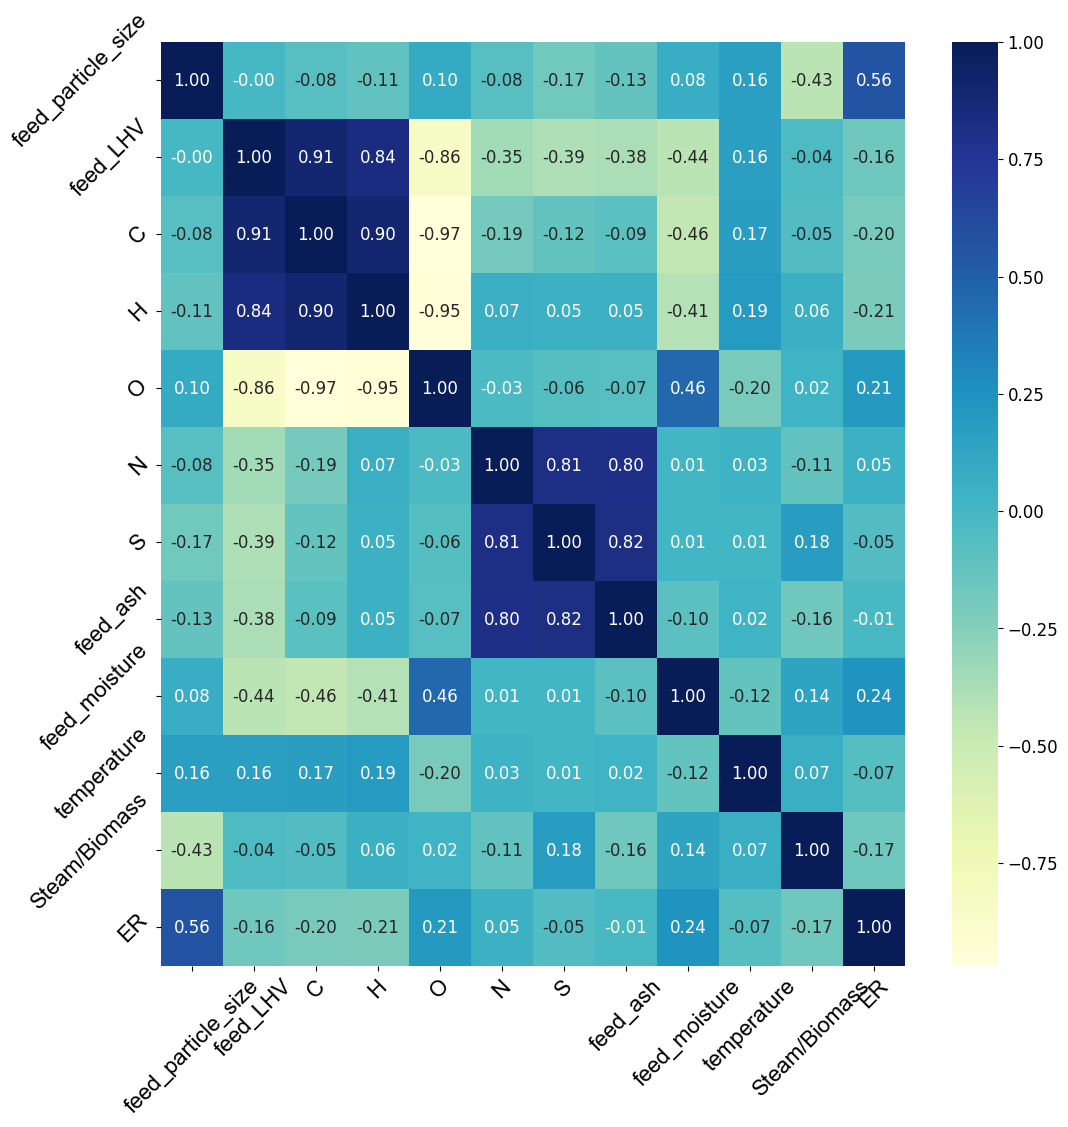

Show highly correlated values with an absolute value greater than 0.6 only


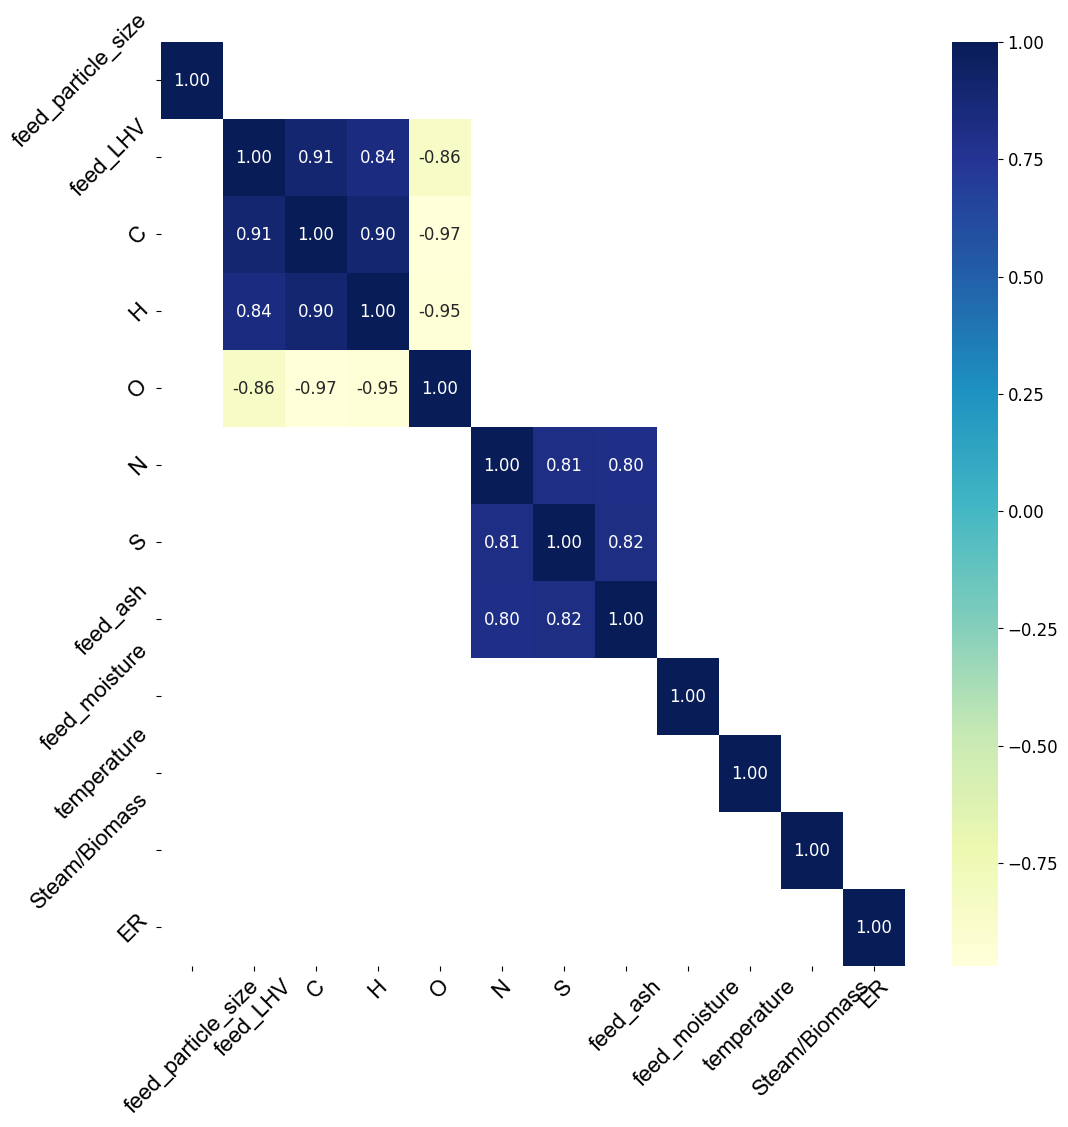


 Spearman correlation coefficient for continous predictor variables


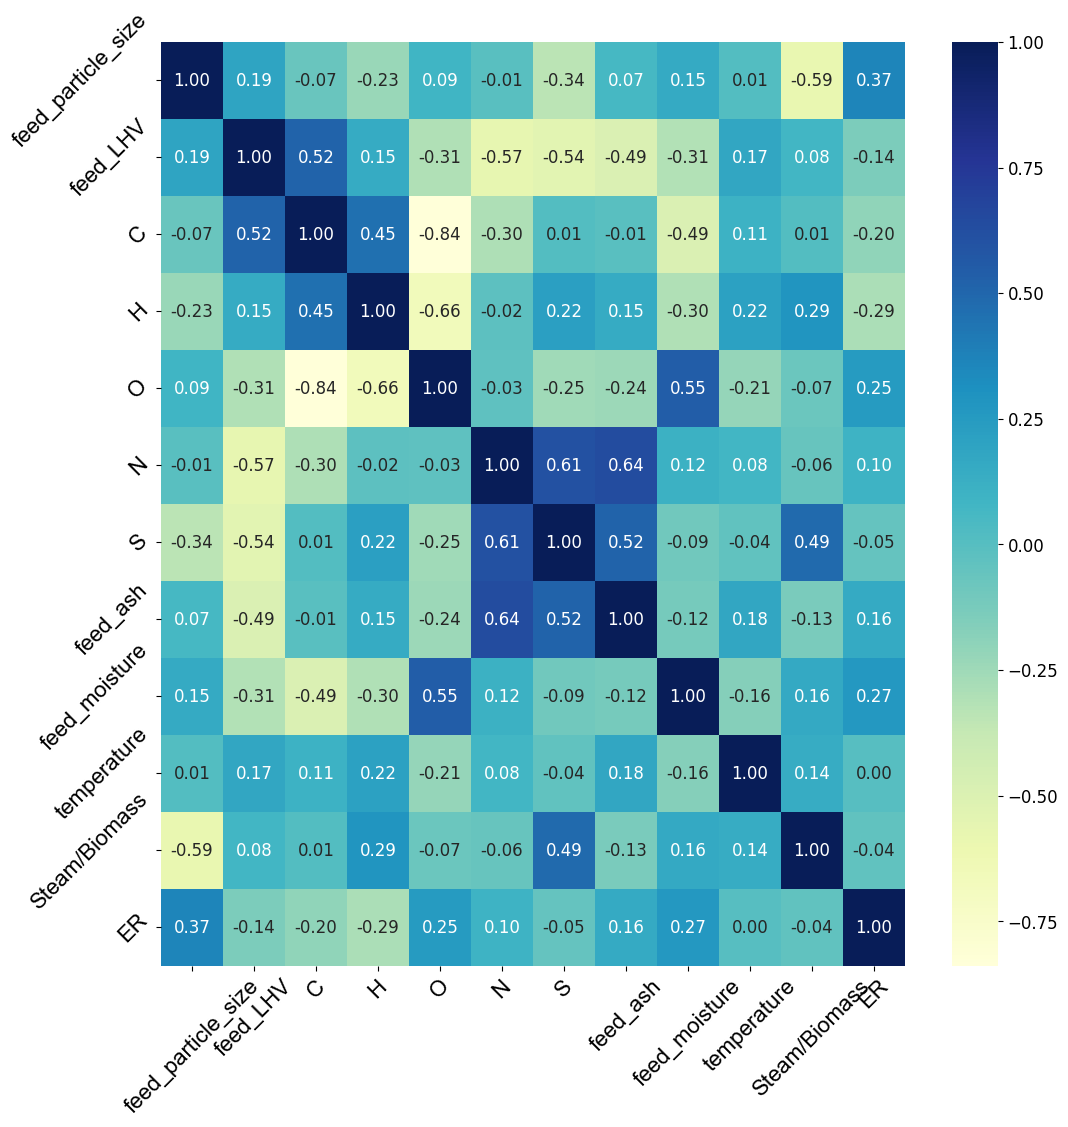

Show highly correlated values with an absolute value greater than 0.6 only


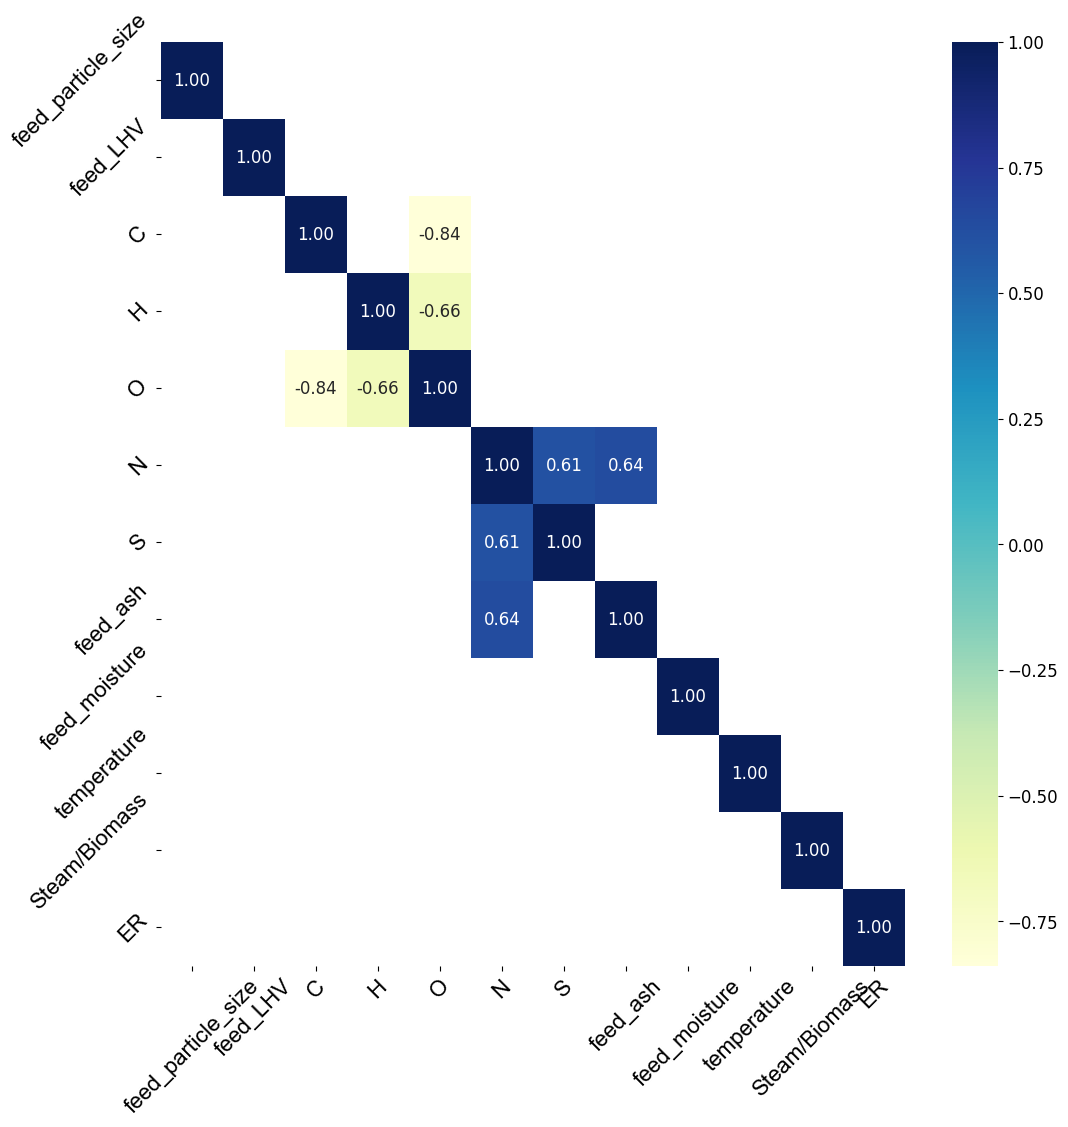

In [87]:
# Plot correlation between continous predictor variables

# Show Pearson correlation coefficients matrix

plt.rcParams.update({'font.size': 12})
rotation_angle = 45

print('Pearson correlation coefficient for continous predictor variables') # to avoid adding titles to figure
plt.figure(figsize=(12,12))
sns.heatmap(clean_input_cont.corr(method='pearson'), annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.show()

# Repeat figure but this time show highly correlated factors ONLY
print('Show highly correlated values with an absolute value greater than {0} only'.format(pearson_corr_threshold))
plt.figure(figsize=(12,12))
pred_pearson_corr = clean_input_cont.corr(method='pearson')
sns.heatmap(pred_pearson_corr[abs(pred_pearson_corr)>=pearson_corr_threshold], annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.show()

# Also show spearman correlation coefficients matrix
print('\n Spearman correlation coefficient for continous predictor variables') # to avoid adding titles to figure
plt.figure(figsize=(12,12))
sns.heatmap(clean_input_cont.corr(method='spearman'), annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
#plt.savefig('figures\Spearman Correlation Matrices\Spearman_Correlation_Coefficient_Matrix.png', dpi=500)
plt.show()

# Repeat figure but this time show highly correlated factors ONLY
print('Show highly correlated values with an absolute value greater than {0} only'.format(spearman_corr_threshold))
plt.figure(figsize=(12,12))
pred_spearman_corr = clean_input_cont.corr(method='spearman')
sns.heatmap(pred_spearman_corr[abs(pred_spearman_corr)>=spearman_corr_threshold], annot=True, cmap="YlGnBu", fmt=".2f")
plt.xticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
plt.yticks(rotation = rotation_angle, fontsize= 16, fontname = "Arial")
#plt.savefig('figures\Spearman Correlation Matrices\Spearman_Correlation_Coefficient_Matrix_HighOnly.png', dpi=500)
plt.show()

In [88]:
clean_input_cat.isna().sum()

feed_type                0
feed_shape               0
operating_condition     10
gasifying_agent          0
reactor_type             0
bed_material           160
catalyst               100
scale                   19
dtype: int64

In [89]:
clean_input_cat.columns = ["Feedstock type", "Feedstock shape", "Operation (Batch/Continuous)", 'Gasifying agent', 'Reactor type', 'Bed material', 'Catalyst (Y/N)', 'Scale (lab/pilot)']
print(clean_input_cat.columns)

for i in clean_input_cat.columns:
    print(f'Categorical of {i} are: {clean_input_cat[i].unique()}')
    print(clean_input_cat[i].value_counts())


Index(['Feedstock type', 'Feedstock shape', 'Operation (Batch/Continuous)',
       'Gasifying agent', 'Reactor type', 'Bed material', 'Catalyst (Y/N)',
       'Scale (lab/pilot)'],
      dtype='object')
Categorical of Feedstock type are: ['municipal solid waste' 'plastics' 'herbaceous biomass' 'woody biomass'
 'sewage sludge' 'other']
Feedstock type
woody biomass            193
herbaceous biomass        74
municipal solid waste     58
plastics                  39
sewage sludge             30
other                     14
Name: count, dtype: int64
Categorical of Feedstock shape are: ['pellets' 'fibres' 'dust' 'other' 'chips' 'particles']
Feedstock shape
pellets      129
particles     94
other         88
chips         45
dust          38
fibres        14
Name: count, dtype: int64
Categorical of Operation (Batch/Continuous) are: ['continuous' 'batch' nan]
Operation (Batch/Continuous)
continuous    374
batch          24
Name: count, dtype: int64
Categorical of Gasifying agent are: ['air' 'a

In [90]:
#Create dataframe for preprocessed categorical input data
input_cat_preprocessed = clean_input_cat.copy()

#Treat and fill missing data
input_cat_preprocessed['Operation (Batch/Continuous)'] = input_cat_preprocessed['Operation (Batch/Continuous)'].fillna(input_cat_preprocessed['Operation (Batch/Continuous)'].mode().iloc[0])

input_cat_preprocessed['Gasifying agent'] = input_cat_preprocessed['Gasifying agent'].replace('air + steam', 'air/steam')

input_cat_preprocessed['Reactor type'] = input_cat_preprocessed['Reactor type'].replace(['horizontal tube', 'bubbling fluidised bed'], 'fluidised bed')

input_cat_preprocessed['Bed material'] = input_cat_preprocessed['Bed material'].replace('alumina ', 'alumina')
input_cat_preprocessed['Bed material'] = input_cat_preprocessed['Bed material'].replace('sand', 'silica')
input_cat_preprocessed['Bed material'] = input_cat_preprocessed['Bed material'].replace('dolomite', 'other')
input_cat_preprocessed['Bed material'] = input_cat_preprocessed['Bed material'].fillna(input_cat_preprocessed['Bed material'].mode().iloc[0])

input_cat_preprocessed['Catalyst (Y/N)'] = input_cat_preprocessed['Catalyst (Y/N)'].fillna(input_cat_preprocessed['Catalyst (Y/N)'].mode().iloc[0])

input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].replace(['pilot-scale (400 kW_th)', 'pilot-scale (500 kW_th)', 'pilot-scale','100 kW_th', '127 kW', 'pilot-scale (~800kW)', '350 kw_th', '100 kW'], 'pilot-scale')
input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].replace(['small-scale (smaller than pilot)', 'laboratory scale', 'laboratory scale (20 kW_th)', 'bench-scale'], 'lab-scale')
input_cat_preprocessed['Scale (lab/pilot)'] = input_cat_preprocessed['Scale (lab/pilot)'].fillna(input_cat_preprocessed['Scale (lab/pilot)'].mode().iloc[0])

In [91]:
input_cat_encoded = input_cat_preprocessed.copy()
#Encode categorical data to numerical data using One Hot encoder
input_cat_encoded = pd.get_dummies(input_cat_preprocessed, columns=['Feedstock type', 'Feedstock shape', 'Gasifying agent', 'Reactor type', 'Bed material'], prefix=['Type', 'Shape', 'Agent', 'Reactor', 'Bed'])

#Encode categorical data to numerical data using ordinal encoder
input_cat_encoded[input_cat_encoded.columns] = OrdinalEncoder().fit_transform(input_cat_encoded[input_cat_encoded.columns])

#Drop unnecessary columns (other)
drop_other = []
for i in input_cat_encoded.columns:
    if i.__contains__('other'):
        drop_other.append(i)
print(drop_other)
input_cat_encoded = input_cat_encoded.drop(drop_other, axis=1)

['Type_other', 'Shape_other', 'Agent_other', 'Reactor_other', 'Bed_other']


In [92]:
for i in input_cat_encoded.columns:
    print(f'Categorical of {i} are: {input_cat_encoded[i].unique()}')
    print(input_cat_encoded[i].value_counts())
    
input_cat_encoded

Categorical of Operation (Batch/Continuous) are: [1. 0.]
Operation (Batch/Continuous)
1.00    384
0.00     24
Name: count, dtype: int64
Categorical of Catalyst (Y/N) are: [1. 0.]
Catalyst (Y/N)
0.00    325
1.00     83
Name: count, dtype: int64
Categorical of Scale (lab/pilot) are: [1. 0.]
Scale (lab/pilot)
1.00    218
0.00    190
Name: count, dtype: int64
Categorical of Type_herbaceous biomass are: [0. 1.]
Type_herbaceous biomass
0.00    334
1.00     74
Name: count, dtype: int64
Categorical of Type_municipal solid waste are: [1. 0.]
Type_municipal solid waste
0.00    350
1.00     58
Name: count, dtype: int64
Categorical of Type_plastics are: [0. 1.]
Type_plastics
0.00    369
1.00     39
Name: count, dtype: int64
Categorical of Type_sewage sludge are: [0. 1.]
Type_sewage sludge
0.00    378
1.00     30
Name: count, dtype: int64
Categorical of Type_woody biomass are: [0. 1.]
Type_woody biomass
0.00    215
1.00    193
Name: count, dtype: int64
Categorical of Shape_chips are: [0. 1.]
Shape_

,Operation (Batch/Continuous),Catalyst (Y/N),Scale (lab/pilot),Type_herbaceous biomass,Type_municipal solid waste,Type_plastics,Type_sewage sludge,Type_woody biomass,Shape_chips,Shape_dust,...,Agent_air,Agent_air/steam,Agent_oxygen,Agent_steam,Agent_steam/oxygen,Reactor_fixed bed,Reactor_fluidised bed,Bed_alumina,Bed_olivine,Bed_silica
0,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
1,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
2,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
3,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
4,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00
404,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
405,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
406,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00


In [93]:
clean_input_cont.describe()


,feed_particle_size,feed_LHV,C,H,O,N,S,feed_ash,feed_moisture,temperature,Steam/Biomass,ER
count,316.00,408.00,408.00,408.00,408.00,408.00,375.00,408.00,408.00,408.00,136.00,335.00
mean,4.52,19.27,53.16,7.12,37.99,1.05,0.34,8.76,7.64,805.01,0.97,0.29
std,6.29,8.11,10.91,2.30,12.80,1.82,0.49,12.48,5.99,71.77,0.71,0.10
min,0.25,11.50,40.07,3.79,0.00,0.00,0.00,0.27,0.00,553.00,0.00,0.09
25%,1.25,14.47,48.32,5.90,33.75,0.15,0.00,1.00,5.13,770.00,0.50,0.23
50%,3.50,18.08,50.00,6.25,42.20,0.44,0.10,2.05,7.65,800.00,0.80,0.30
75%,5.00,19.45,53.31,7.12,44.71,0.97,0.57,13.90,9.34,850.00,1.22,0.32
max,70.00,45.10,86.03,14.23,53.40,7.32,1.90,44.00,51.02,1050.00,4.04,0.87


In [94]:
input_cont_preprocessed = clean_input_cont.copy()

cont_drop_columns = ['Steam/Biomass']
input_cont_preprocessed = input_cont_preprocessed.drop(cont_drop_columns, axis=1)
input_cont_preprocessed

,feed_particle_size,feed_LHV,C,H,O,N,S,feed_ash,feed_moisture,temperature,ER
0,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,849.00,0.26
1,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,852.00,0.26
2,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,869.00,0.27
3,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,879.00,0.30
4,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,898.00,0.32
...,...,...,...,...,...,...,...,...,...,...,...
403,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,0.44
404,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,0.41
405,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,0.33
406,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,0.35


In [95]:
#imputation for Sulphur content (S)
for index, row in input_cont_preprocessed.iterrows():
    # Extract the values of C, H, O, and N
    C = row['C']
    H = row['H']
    O = row['O']
    N = row['N']
    
    # Calculate S
    S = 100 - (C + H + O + N)
    
    # Impute S if it is NaN
    if pd.isna(row['S']):
        input_cont_preprocessed.at[index, 'S'] = S

#imputation for Equivalence Ratio (ER)
input_cont_preprocessed['ER'] = input_cont_preprocessed['ER'].fillna(0.3)

input_cont_preprocessed.describe()

,feed_particle_size,feed_LHV,C,H,O,N,S,feed_ash,feed_moisture,temperature,ER
count,316.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00
mean,4.52,19.27,53.16,7.12,37.99,1.05,0.45,8.76,7.64,805.01,0.30
std,6.29,8.11,10.91,2.30,12.80,1.82,0.96,12.48,5.99,71.77,0.09
min,0.25,11.50,40.07,3.79,0.00,0.00,-0.00,0.27,0.00,553.00,0.09
25%,1.25,14.47,48.32,5.90,33.75,0.15,0.00,1.00,5.13,770.00,0.25
50%,3.50,18.08,50.00,6.25,42.20,0.44,0.09,2.05,7.65,800.00,0.30
75%,5.00,19.45,53.31,7.12,44.71,0.97,0.57,13.90,9.34,850.00,0.32
max,70.00,45.10,86.03,14.23,53.40,7.32,6.50,44.00,51.02,1050.00,0.87


In [96]:

input_cont_preprocessed.columns = ['Particle size (mm)', 'LHV [MJ/kg wb]', 'C [%daf]', 'H [$daf]', 'O [%daf]', 'N [%daf]', 'S [%daf]', 'Ash [%db]', 'Moisture [%wb]', 'Temperature [°C]', 'ER']

treated_input = pd.concat([input_cont_preprocessed, input_cat_encoded], axis=1)
treated_input

,Particle size (mm),LHV [MJ/kg wb],C [%daf],H [$daf],O [%daf],N [%daf],S [%daf],Ash [%db],Moisture [%wb],Temperature [°C],...,Agent_air,Agent_air/steam,Agent_oxygen,Agent_steam,Agent_steam/oxygen,Reactor_fixed bed,Reactor_fluidised bed,Bed_alumina,Bed_olivine,Bed_silica
0,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,849.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
1,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,852.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
2,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,869.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
3,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,879.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
4,5.00,19.45,59.39,8.57,32.30,0.93,0.27,20.69,6.40,898.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,...,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00
404,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
405,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
406,2.00,13.25,52.28,7.82,31.33,6.67,1.90,42.59,6.33,800.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00


In [97]:
#Create list of particle size categorize by feedstock shape
pellets = []
particles = []
other = []
chips = []
dust = []
fibres = []

#Extract data of particle size in to seperated list
for index, row in treated_input.iterrows():
    if row['Particle size (mm)'] == 'NaN':
        continue
    else:
        add = input_cont_preprocessed.loc[index, 'Particle size (mm)']
        if row['Shape_pellets'] == 1:
            pellets.append(add)
        elif row['Shape_particles'] == 1:
            particles.append(add)
        elif row['Shape_chips'] == 1:
            chips.append(add)
        elif row['Shape_dust'] == 1:
            dust.append(add)
        elif row['Shape_fibres'] == 1:
            fibres.append(add)
        else:
            other.append(add)

for index, row in treated_input.iterrows():
    if pd.isna(row['Particle size (mm)']):
        if row['Shape_pellets'] == 1:
            treated_input.at[index, 'Particle size (mm)'] = median(pellets)
        elif row['Shape_particles'] == 1:
            treated_input.at[index, 'Particle size (mm)'] = median(particles)
        elif row['Shape_chips'] == 1:
            treated_input.at[index, 'Particle size (mm)'] = median(chips)
        elif row['Shape_dust'] == 1:
            treated_input.at[index, 'Particle size (mm)'] = median(dust)
        elif row['Shape_fibres'] == 1:
            treated_input.at[index, 'Particle size (mm)'] = median(fibres)
        else:
            treated_input.at[index, 'Particle size (mm)'] = median(other)

In [98]:
treated_input.describe()

,Particle size (mm),LHV [MJ/kg wb],C [%daf],H [$daf],O [%daf],N [%daf],S [%daf],Ash [%db],Moisture [%wb],Temperature [°C],...,Agent_air,Agent_air/steam,Agent_oxygen,Agent_steam,Agent_steam/oxygen,Reactor_fixed bed,Reactor_fluidised bed,Bed_alumina,Bed_olivine,Bed_silica
count,350.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,...,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00,408.00
mean,4.48,19.27,53.16,7.12,37.99,1.05,0.45,8.76,7.64,805.01,...,0.61,0.13,0.04,0.19,0.01,0.18,0.79,0.09,0.08,0.82
std,6.13,8.11,10.91,2.30,12.80,1.82,0.96,12.48,5.99,71.77,...,0.49,0.34,0.21,0.39,0.09,0.39,0.41,0.28,0.28,0.38
min,0.25,11.50,40.07,3.79,0.00,0.00,-0.00,0.27,0.00,553.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.25,14.47,48.32,5.90,33.75,0.15,0.00,1.00,5.13,770.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
50%,3.50,18.08,50.00,6.25,42.20,0.44,0.09,2.05,7.65,800.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
75%,5.00,19.45,53.31,7.12,44.71,0.97,0.57,13.90,9.34,850.00,...,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
max,70.00,45.10,86.03,14.23,53.40,7.32,6.50,44.00,51.02,1050.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [99]:
# Check for any remaining missing values
missing_particle_sizes = treated_input[treated_input['Particle size (mm)'].isna()]
print("Remaining missing particle sizes:")
print(missing_particle_sizes)

Remaining missing particle sizes:
     Particle size (mm)  LHV [MJ/kg wb]  C [%daf]  H [$daf]  O [%daf]  \
20                  NaN           33.40     73.49     11.01     15.43   
21                  NaN           33.40     73.49     11.01     15.43   
22                  NaN           33.40     73.49     11.01     15.43   
23                  NaN           40.20     81.63     13.45      4.62   
24                  NaN           40.20     81.63     13.45      4.62   
302                 NaN           18.60     51.30      5.81     42.60   
303                 NaN           18.60     51.30      5.81     42.60   
304                 NaN           18.60     51.30      5.81     42.60   
333                 NaN           19.20     53.70      6.80     38.99   
334                 NaN           20.40     53.10      6.10     40.60   
335                 NaN           28.30     52.90      5.60     40.10   
336                 NaN           19.70     52.70      6.20     40.80   
337              

In [100]:
print(treated_input.columns)

Index(['Particle size (mm)', 'LHV [MJ/kg wb]', 'C [%daf]', 'H [$daf]',
       'O [%daf]', 'N [%daf]', 'S [%daf]', 'Ash [%db]', 'Moisture [%wb]',
       'Temperature [°C]', 'ER', 'Operation (Batch/Continuous)',
       'Catalyst (Y/N)', 'Scale (lab/pilot)', 'Type_herbaceous biomass',
       'Type_municipal solid waste', 'Type_plastics', 'Type_sewage sludge',
       'Type_woody biomass', 'Shape_chips', 'Shape_dust', 'Shape_fibres',
       'Shape_particles', 'Shape_pellets', 'Agent_air', 'Agent_air/steam',
       'Agent_oxygen', 'Agent_steam', 'Agent_steam/oxygen',
       'Reactor_fixed bed', 'Reactor_fluidised bed', 'Bed_alumina',
       'Bed_olivine', 'Bed_silica'],
      dtype='object')
